### Wstęp do Uczenia Maszynowego - praca domowa 3
##### Stanisław Frelik
##### 11.12.2023

### CZĘŚĆ PIERWSZA
---------

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn import tree
from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_score
from sklearn.metrics import roc_curve, roc_auc_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import accuracy_score, recall_score, precision_score
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import precision_score, roc_auc_score, recall_score, roc_curve
import sklearn.model_selection as skm
from sklearn.svm import SVC
from sklearn . datasets import fetch_openml

In [9]:
n = 200
p = 5
beta_0 = 1
beta_1 = np.array([2, 1, 0.5, 0.01, 0])
X = np.random.normal(0, 1, size = (n, p))
Xbeta = X@beta_1+beta_0
probs = np.exp(Xbeta)/(1+np.exp(Xbeta)) 
y = np.random.binomial(1, probs) 

In [11]:
X = pd.DataFrame(X)

In [15]:
X

,0,1,2,3,4
0,1.885897,0.507939,-0.943329,0.779800,-0.349456
1,0.769453,0.387791,0.441385,-0.812708,-0.338457
2,0.062158,-0.323612,-0.854335,-1.463293,-0.326379
3,-0.267786,-0.415560,-0.311108,-0.634414,-1.264083
4,-0.566482,2.244152,1.360119,-0.904795,-1.759738
...,...,...,...,...,...
195,0.278803,0.868704,1.071628,0.559565,-0.169822
196,-0.088562,0.014667,0.162645,0.879135,-1.454525
197,-0.181442,-0.062039,-0.380660,0.339204,-1.169905
198,1.702498,-1.022635,0.507785,0.195651,0.166182


In [12]:
p_X, n_X = X.shape

In [19]:
np.zeros(5)

array([0., 0., 0., 0., 0.])

In [10]:
def knn(X, y, Z, k, p = 2):
    # opis
    
    # testy
    X = pd.DataFrame(X)
    p_X, n_X = X.shape
    y = np.array(y)
    n = len(y)
    Z = pd.DataFrame(Z)
    p_Z, m_Z = Z.shape

    if not n_X == n:
        raise ValueError("X and y not the same length")
    if not p_X == p_Z:
        raise ValueError("X and Z not the same length")
    if not isinstance(k, int):
        raise ValueError("k is not an int")
    if not 1<=k<=n:
        raise ValueError("k not between 1 and n")
    if not p==np.inf:
        if not isinstance(p, float):
            raise ValueError("p not real")
        if not 1 <= p:
            raise ValueError("p to small :(")
    # dalej
    w = np.zeros(m_Z)
    for i in range(1, m_Z + 1):
        

    return w



In [8]:
k = 3.5
if not isinstance(k, int):
   raise ValueError("k is not an int")

ValueError: k is not an int

#### CZĘŚĆ PIERWSZA
--------

Model regresji logistycznej bez regularyzacji

1. Opytmalizujemy hiperparametry

In [30]:
kfold = skm.KFold(10,
                  random_state=0,
                  shuffle=True)


In [31]:
logr = LogisticRegression(penalty=None)

In [32]:
parameters = {'solver':('lbfgs', 'newton-cg', 'newton-cholesky','sag', 'saga'), 
              'max_iter':[1000, 1200, 1400, 1600, 1800, 2000], 
              'multi_class':('auto', 'ovr', 'multinomial'),
              'fit_intercept':(True, False)}
grid = skm.GridSearchCV(logr,
                        parameters, 
                         refit=True,
                         cv=kfold,
                         n_jobs=-1,
                         scoring='accuracy')

In [33]:
grid.fit(X_train, y_train)

c:\Users\stani\anaconda3\lib\site-packages\sklearn\model_selection\_validation.py:425: FitFailedWarning: 
120 fits failed out of a total of 1800.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
120 fits failed with the following error:
Traceback (most recent call last):
  File "c:\Users\stani\anaconda3\lib\site-packages\sklearn\model_selection\_validation.py", line 729, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "c:\Users\stani\anaconda3\lib\site-packages\sklearn\base.py", line 1152, in wrapper
    return fit_method(estimator, *args, **kwargs)
  File "c:\Users\stani\anaconda3\lib\site-packages\sklearn\linear_model\_logistic.py", line 1219, in fit
    multi_class = _check_multi_class(self.multi_class, solve

GridSearchCV(cv=KFold(n_splits=10, random_state=0, shuffle=True),
             estimator=LogisticRegression(penalty=None), n_jobs=-1,
             param_grid={'fit_intercept': (True, False),
                         'max_iter': [1000, 1200, 1400, 1600, 1800, 2000],
                         'multi_class': ('auto', 'ovr', 'multinomial'),
                         'solver': ('lbfgs', 'newton-cg', 'newton-cholesky',
                                    'sag', 'saga')},
             scoring='accuracy')

In [34]:
grid.best_params_

{'fit_intercept': True,
 'max_iter': 1600,
 'multi_class': 'auto',
 'solver': 'newton-cholesky'}

2. Oceniamy wybrane parametry

In [35]:
logr = LogisticRegression(penalty=None,
 fit_intercept = True,
 max_iter = 1600,
 multi_class = 'auto',
 solver = 'newton-cholesky')
logr.fit(X_train, y_train)
y_pred_logr = logr.predict(X_test)
pred_logr = logr.predict_proba(X_test)

c:\Users\stani\anaconda3\lib\site-packages\sklearn\linear_model\_glm\_newton_solver.py:498: LinAlgWarning: The inner solver of NewtonCholeskySolver stumbled upon a singular or very ill-conditioned Hessian matrix at iteration #1. It will now resort to lbfgs instead.
Further options are to use another solver or to avoid such situation in the first place. Possible remedies are removing collinear features of X or increasing the penalization strengths.
The original Linear Algebra message was:
Ill-conditioned matrix (rcond=9.19653e-25): result may not be accurate.
  warnings.warn(
c:\Users\stani\anaconda3\lib\site-packages\sklearn\linear_model\_glm\_newton_solver.py:195: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  self.n_iter_ = _check_optimize_result("lbfgs", opt_res)


In [50]:
print("none accuracy score:", np.round(accuracy_score(y_test, y_pred_logr), 3))
print("none precision score:", np.round(precision_score(y_test, y_pred_logr, pos_label='good'), 3))
print("none recall score:", np.round(recall_score(y_test, y_pred_logr, pos_label='good'), 3))
print("none auc score:", np.round(roc_auc_score(y_test, pred_logr[:,1]), 3))

none accuracy score: 0.777
none precision score: 0.796
none recall score: 0.92
none auc score: 0.784


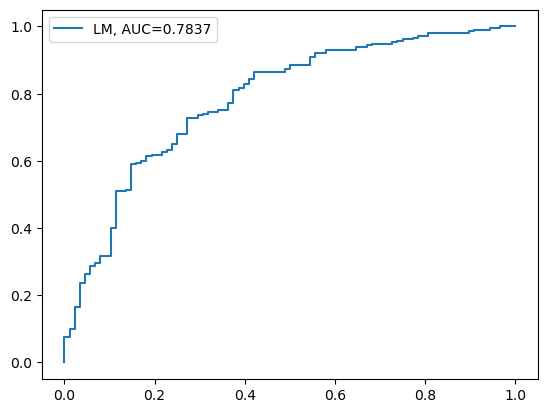

In [51]:
fpr, tpr, thresholds = roc_curve(y_test, pred_logr[:,1], pos_label='good')
plt.plot(fpr,tpr,label="LM, AUC="+str(round(roc_auc_score(y_test, pred_logr[:,1]), 4)))
plt.legend()

Regresja logistyczna z regularyzacją L1

1. Opytmalizujemy hiperparametry

In [38]:
kfold = skm.KFold(10,
                  random_state=0,
                  shuffle=True)

In [39]:
logr = LogisticRegression(penalty='l1')

In [40]:
parameters = {'solver':('liblinear', 'saga'), 
              'max_iter':[1000, 1100, 1200, 1300], 
              'multi_class':('auto', 'ovr', 'multinomial'),
              'fit_intercept':(True, False),
              'tol':[1e-7, 1e-6, 1e-5], 
              'C': [1e-1, 1, 5]}
grid = skm.GridSearchCV(logr,
                        parameters, 
                         refit=True,
                         cv=kfold,
                         n_jobs=-1,
                         scoring='accuracy')

In [41]:
grid.fit(X_train, y_train)

c:\Users\stani\anaconda3\lib\site-packages\sklearn\model_selection\_validation.py:425: FitFailedWarning: 
720 fits failed out of a total of 4320.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
720 fits failed with the following error:
Traceback (most recent call last):
  File "c:\Users\stani\anaconda3\lib\site-packages\sklearn\model_selection\_validation.py", line 729, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "c:\Users\stani\anaconda3\lib\site-packages\sklearn\base.py", line 1152, in wrapper
    return fit_method(estimator, *args, **kwargs)
  File "c:\Users\stani\anaconda3\lib\site-packages\sklearn\linear_model\_logistic.py", line 1219, in fit
    multi_class = _check_multi_class(self.multi_class, solve

GridSearchCV(cv=KFold(n_splits=10, random_state=0, shuffle=True),
             estimator=LogisticRegression(penalty='l1'), n_jobs=-1,
             param_grid={'C': [0.1, 1, 5], 'fit_intercept': (True, False),
                         'max_iter': [1000, 1100, 1200, 1300],
                         'multi_class': ('auto', 'ovr', 'multinomial'),
                         'solver': ('liblinear', 'saga'),
                         'tol': [1e-07, 1e-06, 1e-05]},
             scoring='accuracy')

In [42]:
grid.best_params_

{'C': 1,
 'fit_intercept': True,
 'max_iter': 1000,
 'multi_class': 'auto',
 'solver': 'liblinear',
 'tol': 1e-07}

2. Oceniamy wybrane parametry

In [4]:
logr_l1 = LogisticRegression(penalty="l1",
 C =1,
 fit_intercept = True,
 max_iter = 1000,
 multi_class = 'auto',
 solver = 'liblinear',
 tol = 1e-7)
logr_l1.fit(X_train, y_train)
y_pred_logr_l1 = logr_l1.predict(X_test)
pred_logr_l1 = logr_l1.predict_proba(X_test)

In [52]:
print("l1 accuracy score:", np.round(accuracy_score(y_test, y_pred_logr_l1), 3))
print("l1 precision score:", np.round(precision_score(y_test, y_pred_logr_l1, pos_label='good'), 3))
print("l1 recall score:", np.round(recall_score(y_test, y_pred_logr_l1, pos_label='good'), 3))
print("l1 auc score:", np.round(roc_auc_score(y_test, pred_logr_l1[:,1]), 3))

l1 accuracy score: 0.767
l1 precision score: 0.793
l1 recall score: 0.906
l1 auc score: 0.784


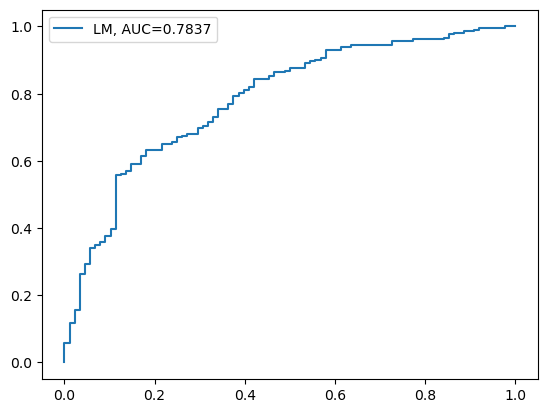

In [53]:
fpr, tpr, thresholds = roc_curve(y_test, pred_logr_l1[:,1], pos_label='good')
plt.plot(fpr,tpr,label="LM, AUC="+str(round(roc_auc_score(y_test, pred_logr_l1[:,1]), 4)))
plt.legend()

Regresja logistyczna z regularyzacją L2


1. Opytmalizujemy hiperparametry

In [43]:
kfold = skm.KFold(10,
                  random_state=0,
                  shuffle=True)

In [44]:
logr_l2 = LogisticRegression(penalty='l2')

In [45]:
parameters = {'solver':('lbfgs', 'liblinear', 'newton-cg','newton-cholesky','sag','saga'), 
              'max_iter':[1000, 1100, 1200], 
              'multi_class':('auto', 'ovr', 'multinomial'),
              'fit_intercept':(True, False),
              'tol':[1e-6, 1e-5, 1e-7], 
              'C': [1e-2, 1e-1, 1],
              'dual':(True, False)}
grid = skm.GridSearchCV(logr_l2,
                        parameters, 
                         refit=True,
                         cv=kfold,
                         n_jobs=-1,
                         scoring='accuracy')

In [46]:
grid.fit(X_train, y_train)

c:\Users\stani\anaconda3\lib\site-packages\sklearn\model_selection\_validation.py:425: FitFailedWarning: 
9720 fits failed out of a total of 19440.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
1620 fits failed with the following error:
Traceback (most recent call last):
  File "c:\Users\stani\anaconda3\lib\site-packages\sklearn\model_selection\_validation.py", line 729, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "c:\Users\stani\anaconda3\lib\site-packages\sklearn\base.py", line 1152, in wrapper
    return fit_method(estimator, *args, **kwargs)
  File "c:\Users\stani\anaconda3\lib\site-packages\sklearn\linear_model\_logistic.py", line 1169, in fit
    solver = _check_solver(self.solver, self.penalty, sel

GridSearchCV(cv=KFold(n_splits=10, random_state=0, shuffle=True),
             estimator=LogisticRegression(), n_jobs=-1,
             param_grid={'C': [0.01, 0.1, 1], 'dual': (True, False),
                         'fit_intercept': (True, False),
                         'max_iter': [1000, 1100, 1200],
                         'multi_class': ('auto', 'ovr', 'multinomial'),
                         'solver': ('lbfgs', 'liblinear', 'newton-cg',
                                    'newton-cholesky', 'sag', 'saga'),
                         'tol': [1e-06, 1e-05, 1e-07]},
             scoring='accuracy')

In [47]:
grid.best_params_

{'C': 0.1,
 'dual': False,
 'fit_intercept': True,
 'max_iter': 1000,
 'multi_class': 'auto',
 'solver': 'liblinear',
 'tol': 1e-06}

2. Oceniamy wybrane parametry

In [48]:
logr_l2 = LogisticRegression(penalty="l2",
 C = 0.1,
 dual = False, 
 fit_intercept = True,
 max_iter = 1000,
 multi_class = 'auto',
 solver = 'liblinear',
 tol = 1e-6)
logr_l2.fit(X_train, y_train)
y_pred_logr_l2 = logr_l2.predict(X_test)
pred_logr_l2 = logr_l2.predict_proba(X_test)

In [54]:
print("l2 accuracy score:", np.round(accuracy_score(y_test, y_pred_logr_l2), 3))
print("l2 precision score:", np.round(precision_score(y_test, y_pred_logr_l2, pos_label='good'), 3))
print("l2 recall score:", np.round(recall_score(y_test, y_pred_logr_l2, pos_label='good'), 3))
print("l2 auc score:", np.round(roc_auc_score(y_test, pred_logr_l2[:,1]), 3))

l2 accuracy score: 0.767
l2 precision score: 0.789
l2 recall score: 0.915
l2 auc score: 0.78


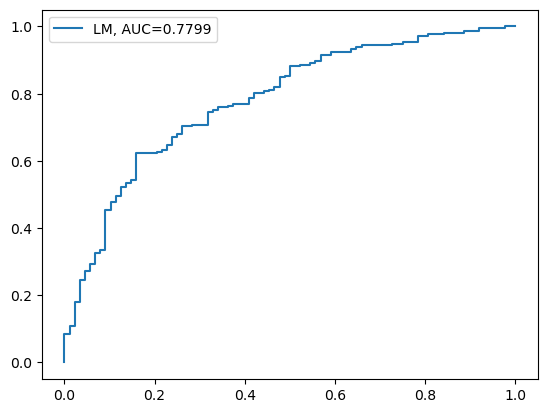

In [55]:
fpr, tpr, thresholds = roc_curve(y_test, pred_logr_l2[:,1], pos_label='good')
plt.plot(fpr,tpr,label="LM, AUC="+str(round(roc_auc_score(y_test, pred_logr_l2[:,1]), 4)))
plt.legend()

Podsumowanie

In [7]:
np.where(logr_l1.coef_[0] < 0.01)[0]

array([ 0,  1,  2,  5,  6,  8,  9, 11, 13, 15, 16, 17, 18, 19, 20, 23, 24,
       26, 27, 28, 31, 33, 34, 35, 36, 37, 40, 42, 44, 45, 47, 49, 50, 52,
       54, 55, 56, 57, 60], dtype=int64)

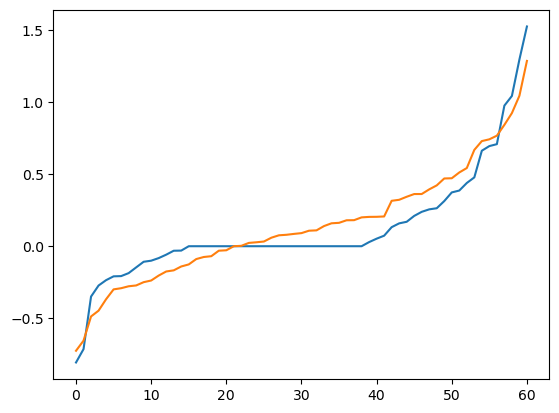

In [13]:
u = list(range(0, 61))
plt.plot(u,sorted(logr_l1.coef_[0]))
plt.plot(u, sorted(logr_l2.coef_[0]))

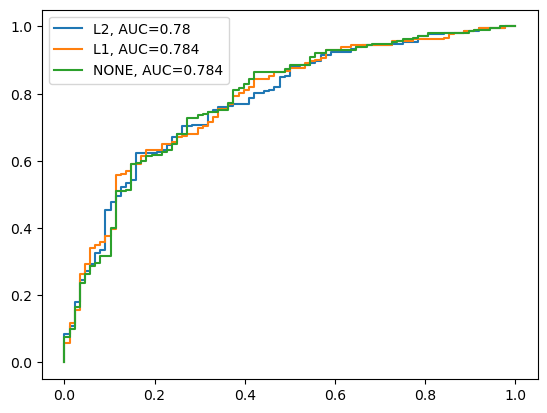

In [56]:
fpr, tpr, thresholds = roc_curve(y_test, pred_logr_l2[:,1], pos_label='good')
plt.plot(fpr,tpr,label="L2, AUC="+str(round(roc_auc_score(y_test, pred_logr_l2[:,1]), 3)))


fpr, tpr, thresholds = roc_curve(y_test, pred_logr_l1[:,1], pos_label='good')
plt.plot(fpr,tpr,label="L1, AUC="+str(round(roc_auc_score(y_test, pred_logr_l1[:,1]), 3)))


fpr, tpr, thresholds = roc_curve(y_test, pred_logr[:,1], pos_label='good')
plt.plot(fpr,tpr,label="NONE, AUC="+str(round(roc_auc_score(y_test, pred_logr[:,1]), 3)))
plt.legend()

A czy base jest lepszy?

In [5]:
logr_test = LogisticRegression()
logr_test.fit(X_train, y_train)
y_pred_logr_test = logr_test.predict(X_test)
pred_logr_test = logr_test.predict_proba(X_test)

accuracy score: 0.76
precision score: 0.794
recall score: 0.892
auc score: 0.774


c:\Users\stani\anaconda3\lib\site-packages\sklearn\linear_model\_logistic.py:460: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [6]:
print("accuracy score:", np.round(accuracy_score(y_test, y_pred_logr_test), 3))
print("precision score:", np.round(precision_score(y_test, y_pred_logr_test, pos_label='good'), 3))
print("recall score:", np.round(recall_score(y_test, y_pred_logr_test, pos_label='good'), 3))
print("auc score:", np.round(roc_auc_score(y_test, pred_logr_test[:,1]), 3))

accuracy score: 0.76
precision score: 0.794
recall score: 0.892
auc score: 0.774


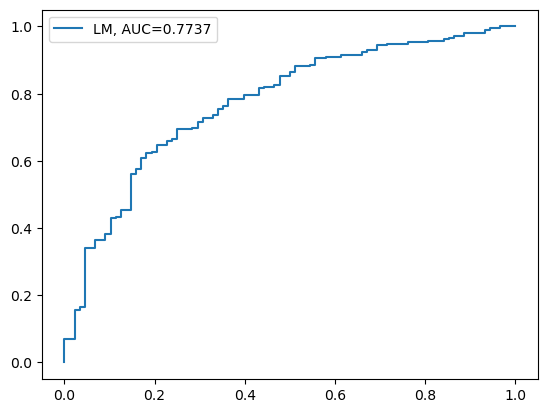

In [7]:
fpr, tpr, thresholds = roc_curve(y_test, pred_logr_test[:,1], pos_label='good')
plt.plot(fpr,tpr,label="LM, AUC="+str(round(roc_auc_score(y_test, pred_logr_test[:,1]), 4)))
plt.legend()

no tak średnio

### CZĘŚĆ DRUGA
--------------------
Usuwamy te kolumny, które podpowiada nam "l1"

In [77]:
np.where(logr_l1.coef_[0] < 0.001)[0]

array([ 0,  1,  2,  5,  6,  8,  9, 11, 13, 15, 16, 17, 18, 19, 20, 23, 24,
       26, 27, 28, 31, 33, 34, 35, 36, 37, 40, 42, 44, 45, 47, 49, 50, 52,
       54, 55, 56, 57, 60], dtype=int64)

In [5]:
v = np.where(logr_l1.coef_[0] < 0.001)[0]
X_cut = X.drop(X.columns[v], axis = 1)
X_train_cut, X_test_cut, y_train, y_test = train_test_split(X_cut, y, test_size=0.3, random_state=320553)

Dostrajamy parametry modelu SVM

In [71]:
kfold = skm.KFold(10,
                  random_state=0,
                  shuffle=True)
svm_linear = SVC(probability=True, max_iter = -1, kernel = 'linear')
parameters = {'gamma':('scale', 'auto'), 
              'tol':[1, 2, 3, 4, 5, 6, 7, 8, 9, 10], 
              'C': [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]}
grid = skm.GridSearchCV(svm_linear,
                        parameters, 
                         refit=True,
                         cv=kfold,
                         n_jobs=-1,
                         verbose=3)
grid.fit(X_train_cut, y_train)

Fitting 10 folds for each of 200 candidates, totalling 2000 fits


GridSearchCV(cv=KFold(n_splits=10, random_state=0, shuffle=True),
             estimator=SVC(kernel='linear', probability=True), n_jobs=-1,
             param_grid={'C': [1, 2, 3, 4, 5, 6, 7, 8, 9, 10],
                         'gamma': ('scale', 'auto'),
                         'tol': [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]},
             verbose=3)

In [72]:
grid.best_params_

{'C': 6, 'gamma': 'scale', 'tol': 2}

Oceniamy model SVM

In [78]:
svm = SVC(probability=True, max_iter = -1, kernel = 'linear', C = 6, gamma = 'scale', tol = 2)

In [79]:
svm.fit(X_train_cut, y_train)
y_pred_svm = svm.predict(X_test_cut)
pred_svm = svm.predict_proba(X_test_cut)

In [80]:
print("accuracy score:", np.round(accuracy_score(y_test, y_pred_svm), 3))
print("precision score:", np.round(precision_score(y_test, y_pred_svm, pos_label='good'), 3))
print("recall score:", np.round(recall_score(y_test, y_pred_svm, pos_label='good'), 3))
print("auc score:", np.round(roc_auc_score(y_test, pred_svm[:,1]), 3))

accuracy score: 0.723
precision score: 0.77
recall score: 0.868
auc score: 0.734


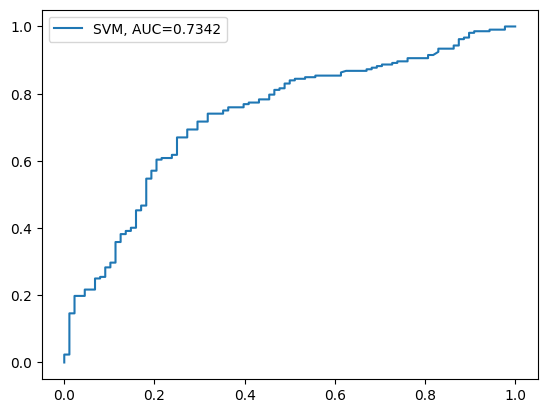

In [76]:
fpr, tpr, thresholds = roc_curve(y_test, pred_svm[:,1], pos_label='good')
plt.plot(fpr,tpr,label="SVM, AUC="+str(round(roc_auc_score(y_test, pred_svm[:,1]), 4)))
plt.legend()